!pip install tensorflow

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.21.0


In [2]:
# Load IMDB dataset
# num_words=10000 means we only keep top 10,000 most common words
NUM_WORDS = 10000

(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=NUM_WORDS)

print("Training samples:", len(X_train))
print("Test samples    :", len(X_test))
print("\nLabel meanings: 0 = Negative Review, 1 = Positive Review")
print("Sample labels:", y_train[:5])


C:\Users\Pratham\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\numpy\lib\_format_impl.py:838: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  array = pickle.load(fp, **pickle_kwargs)


Training samples: 25000
Test samples    : 25000

Label meanings: 0 = Negative Review, 1 = Positive Review
Sample labels: [1 0 0 1 0]


In [3]:
# Each review is a list of word-index numbers
print("Sample review (as word indexes):")
print(X_train[0][:20], "...")
print("\nLength of first review:", len(X_train[0]))
print("Length of second review:", len(X_train[1]))


Sample review (as word indexes):
[1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25] ...

Length of first review: 218
Length of second review: 189


In [4]:
# Decode a review back to words (optional - just for understanding)
word_index = imdb.get_word_index()
reverse_word_index = {v: k for k, v in word_index.items()}

def decode_review(encoded):
    return ' '.join([reverse_word_index.get(i - 3, '?') for i in encoded])

print("Decoded sample review:")
print(decode_review(X_train[0][:50]))
print("\nLabel:", "Positive" if y_train[0] == 1 else "Negative")


Decoded sample review:
? this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert ? is an amazing actor and now the same being director ? father came from the same scottish island as myself so i loved

Label: Positive


In [5]:
# All reviews must be same length for neural network
# We pad/trim them to 200 words
MAX_LEN = 200

X_train = pad_sequences(X_train, maxlen=MAX_LEN, padding='post', truncating='post')
X_test  = pad_sequences(X_test,  maxlen=MAX_LEN, padding='post', truncating='post')

print("After padding:")
print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)


After padding:
X_train shape: (25000, 200)
X_test shape : (25000, 200)


In [6]:
# Build the DNN model for binary classification
EMBEDDING_DIM = 16

model = keras.Sequential([
    # Embedding layer: converts word indices to dense vectors
    keras.layers.Embedding(input_dim=NUM_WORDS, output_dim=EMBEDDING_DIM, input_length=MAX_LEN),

    # Flatten the sequence into a single vector
    keras.layers.GlobalAveragePooling1D(),

    # Hidden layer 1
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dropout(0.5),

    # Hidden layer 2
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dropout(0.3),

    # Output layer: sigmoid for binary classification (0 or 1)
    keras.layers.Dense(1, activation='sigmoid')
])

# Compile the model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',   # Binary Cross-Entropy for binary classification
    metrics=['accuracy']
)

# Display model architecture
model.summary()


C:\Users\Pratham\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling1d             │ ?                           │               0 │
│ (GlobalAveragePooling1D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [9]:
# Train the model
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)

print("\nTraining complete!")


Epoch 1/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.9653 - loss: 0.1179 - val_accuracy: 0.8688 - val_loss: 0.4232
Epoch 2/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.9694 - loss: 0.1040 - val_accuracy: 0.8536 - val_loss: 0.4733
Epoch 3/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.9644 - loss: 0.1142 - val_accuracy: 0.8642 - val_loss: 0.4787
Epoch 4/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9679 - loss: 0.1037 - val_accuracy: 0.8490 - val_loss: 0.5496
Epoch 5/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.9721 - loss: 0.0899 - val_accuracy: 0.8590 - val_loss: 0.5484
Epoch 6/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.9700 - loss: 0.0941 - val_accuracy: 0.8652 - val_loss: 0.5264
Epoch 7/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.9787 - loss: 0.0756 - val_accuracy: 0.8636 - val_loss: 0.5806
Epoch 8/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.9794 - loss: 0.0704 - val_accu

In [10]:
# Evaluate on test data
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

print("Test Results:")
print(f"  Test Loss     : {test_loss:.4f}")
print(f"  Test Accuracy : {test_acc*100:.2f}%")


Test Results:
  Test Loss     : 0.8049
  Test Accuracy : 82.87%


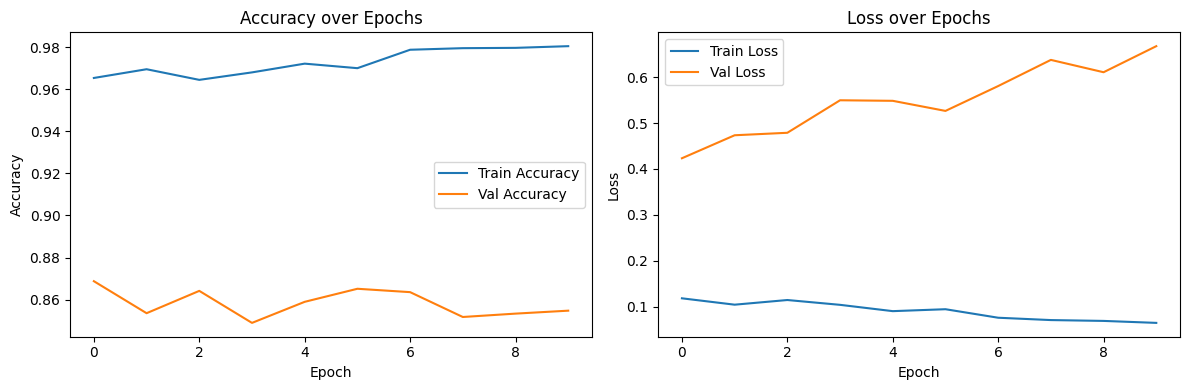

In [11]:
plt.figure(figsize=(12, 4))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


In [12]:
# Predict sentiment of a new review
def predict_sentiment(review_index):
    sample = X_test[review_index].reshape(1, -1)
    prediction = model.predict(sample, verbose=0)[0][0]
    actual = "Positive" if y_test[review_index] == 1 else "Negative"
    predicted = "Positive" if prediction > 0.5 else "Negative"
    confidence = prediction if prediction > 0.5 else (1 - prediction)
    
    print(f"Actual Sentiment   : {actual}")
    print(f"Predicted Sentiment: {predicted}")
    print(f"Confidence         : {confidence*100:.1f}%")

# Test with first 3 reviews
for i in range(3):
    print(f"\n--- Review {i+1} ---")
    predict_sentiment(i)



--- Review 1 ---
Actual Sentiment   : Negative
Predicted Sentiment: Negative
Confidence         : 97.6%

--- Review 2 ---
Actual Sentiment   : Positive
Predicted Sentiment: Positive
Confidence         : 100.0%

--- Review 3 ---
Actual Sentiment   : Positive
Predicted Sentiment: Negative
Confidence         : 90.0%


## Conclusion

- We built a **Binary Classification** model using DNN to classify IMDB reviews.
- **Embedding layer** converts word indexes to dense vectors.
- **Sigmoid activation** in output gives probability between 0 and 1.
- **Binary Cross-Entropy** is used as loss function for binary classification.
- **Dropout** helps prevent overfitting.
